# Assignment on KNN

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [154]:
df_z1=pd.read_csv("Zoo.csv")

In [156]:
df_z1

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [158]:
df_z1.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [160]:
df_z1.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [162]:
df_z1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [67]:
# 1. Analyse the data using the visualizations

In [164]:
df_z1.columns

Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
      dtype='object')

In [71]:
# Box plot

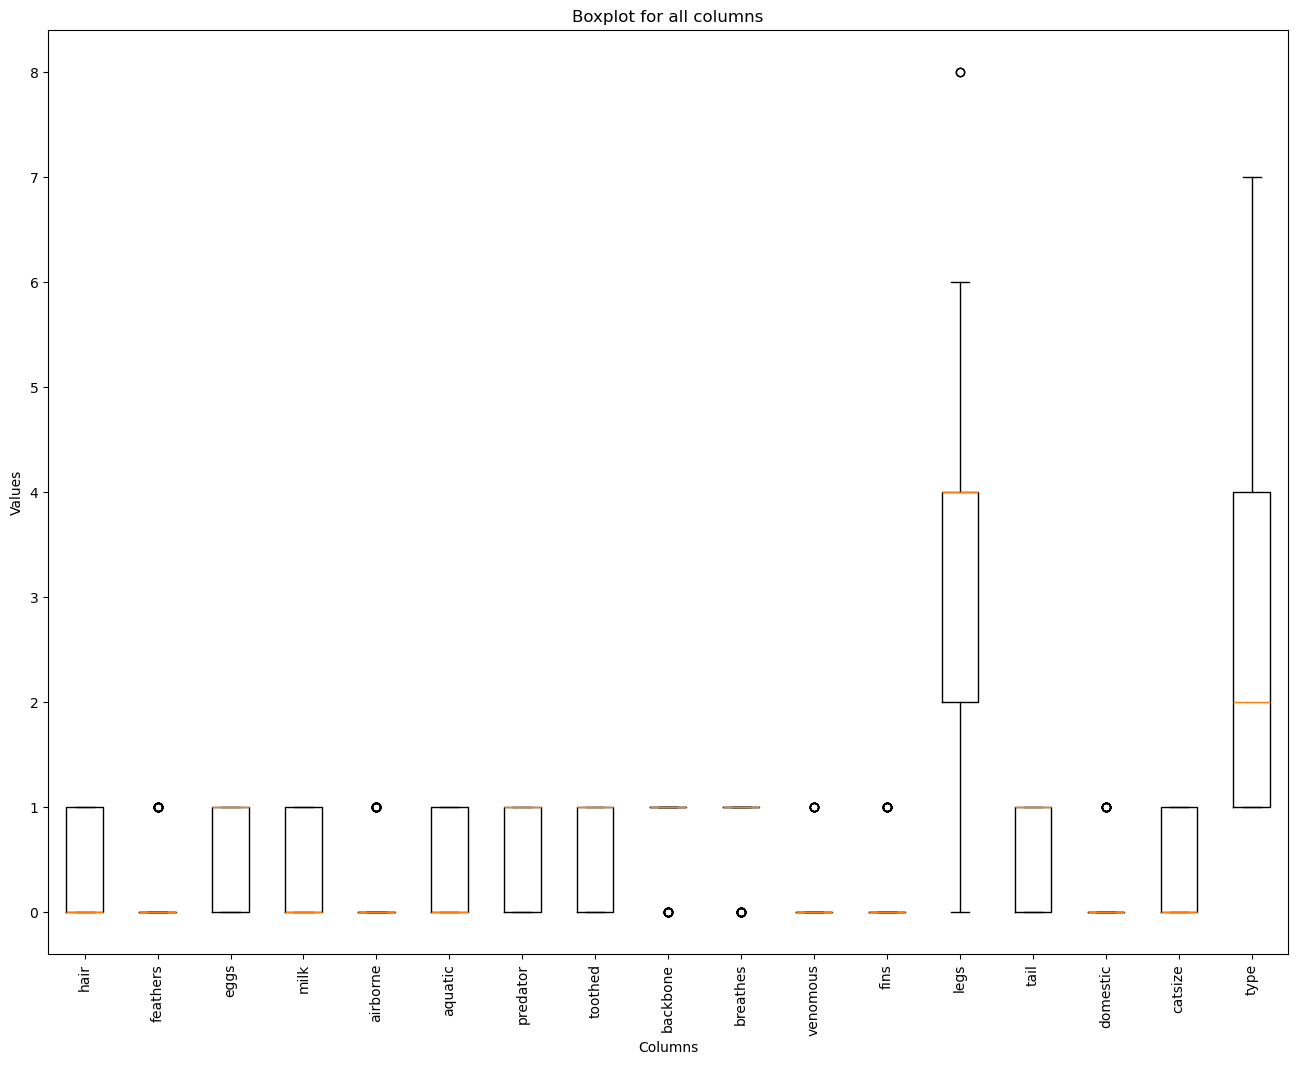

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure df_z contains only numeric columns
df_z = df_z1.select_dtypes(include=[np.number])

# Handle NaN values
# df_z = df_z.dropna()

plt.figure(figsize=(16, 12))
plt.boxplot([df_z[col] for col in df_z.columns], tick_labels=df_z.columns)  # Fixed argument
plt.title('Boxplot for all columns')
plt.xlabel('Columns')
plt.ylabel('Values')
plt.xticks(rotation=90)  # Rotate labels for readability
plt.show()


In [90]:
df_z['feathers'].value_counts()

feathers
0    81
1    20
Name: count, dtype: int64

In [92]:
df_z['airborne'].value_counts()

airborne
0    77
1    24
Name: count, dtype: int64

In [94]:
df_z['backbone'].value_counts()

backbone
1    83
0    18
Name: count, dtype: int64

In [96]:
df_z['breathes'].value_counts()

breathes
1    80
0    21
Name: count, dtype: int64

In [98]:
df_z['venomous'].value_counts()

venomous
0    93
1     8
Name: count, dtype: int64

In [102]:
df_z['fins'].value_counts()

fins
0    84
1    17
Name: count, dtype: int64

In [104]:
df_z['legs'].value_counts()

legs
4    38
2    27
0    23
6    10
8     2
5     1
Name: count, dtype: int64

In [106]:
df_z['domestic'].value_counts()

domestic
0    88
1    13
Name: count, dtype: int64

In [110]:
# Histogram curve

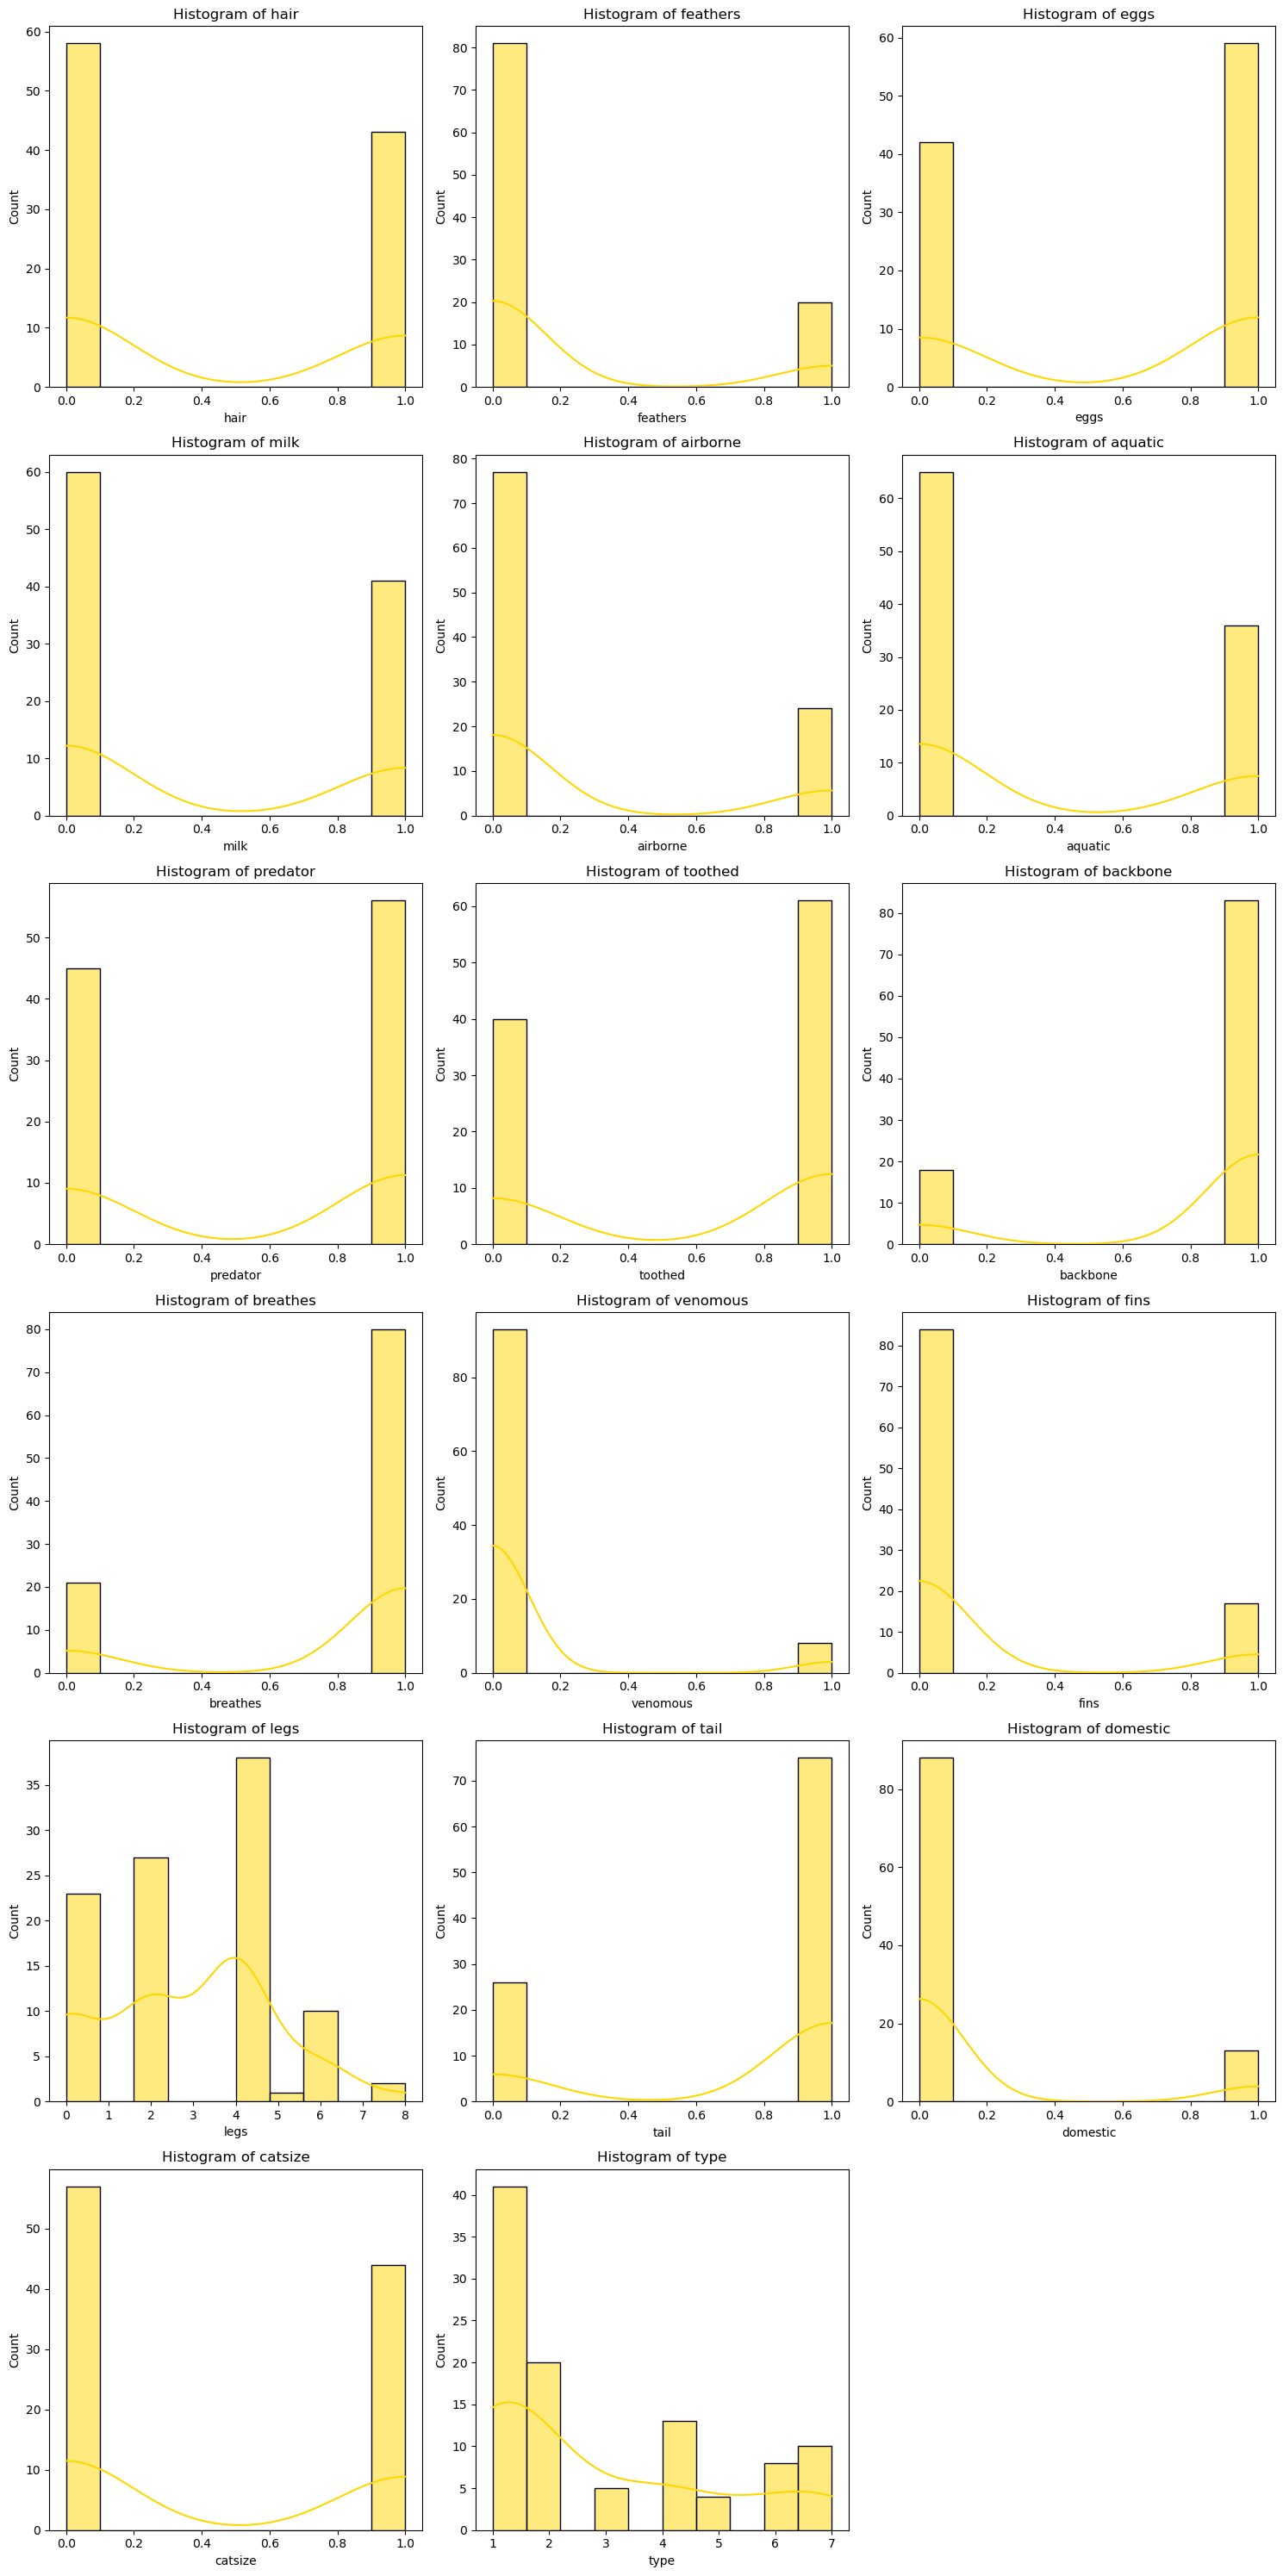

In [132]:
import math
import seaborn as sns

df_numerical=df_z.select_dtypes(include=[np.number])
# Filtered numerical columns

# Number of numerical columns
num_cols=len(df_numerical.columns)
rows=math.ceil(num_cols/3)

plt.figure(figsize=(15,rows*5))
for i,col in enumerate(df_numerical.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(df_numerical[col], kde=True, bins=10, color='gold')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [120]:
# Scatter plot and correlation check

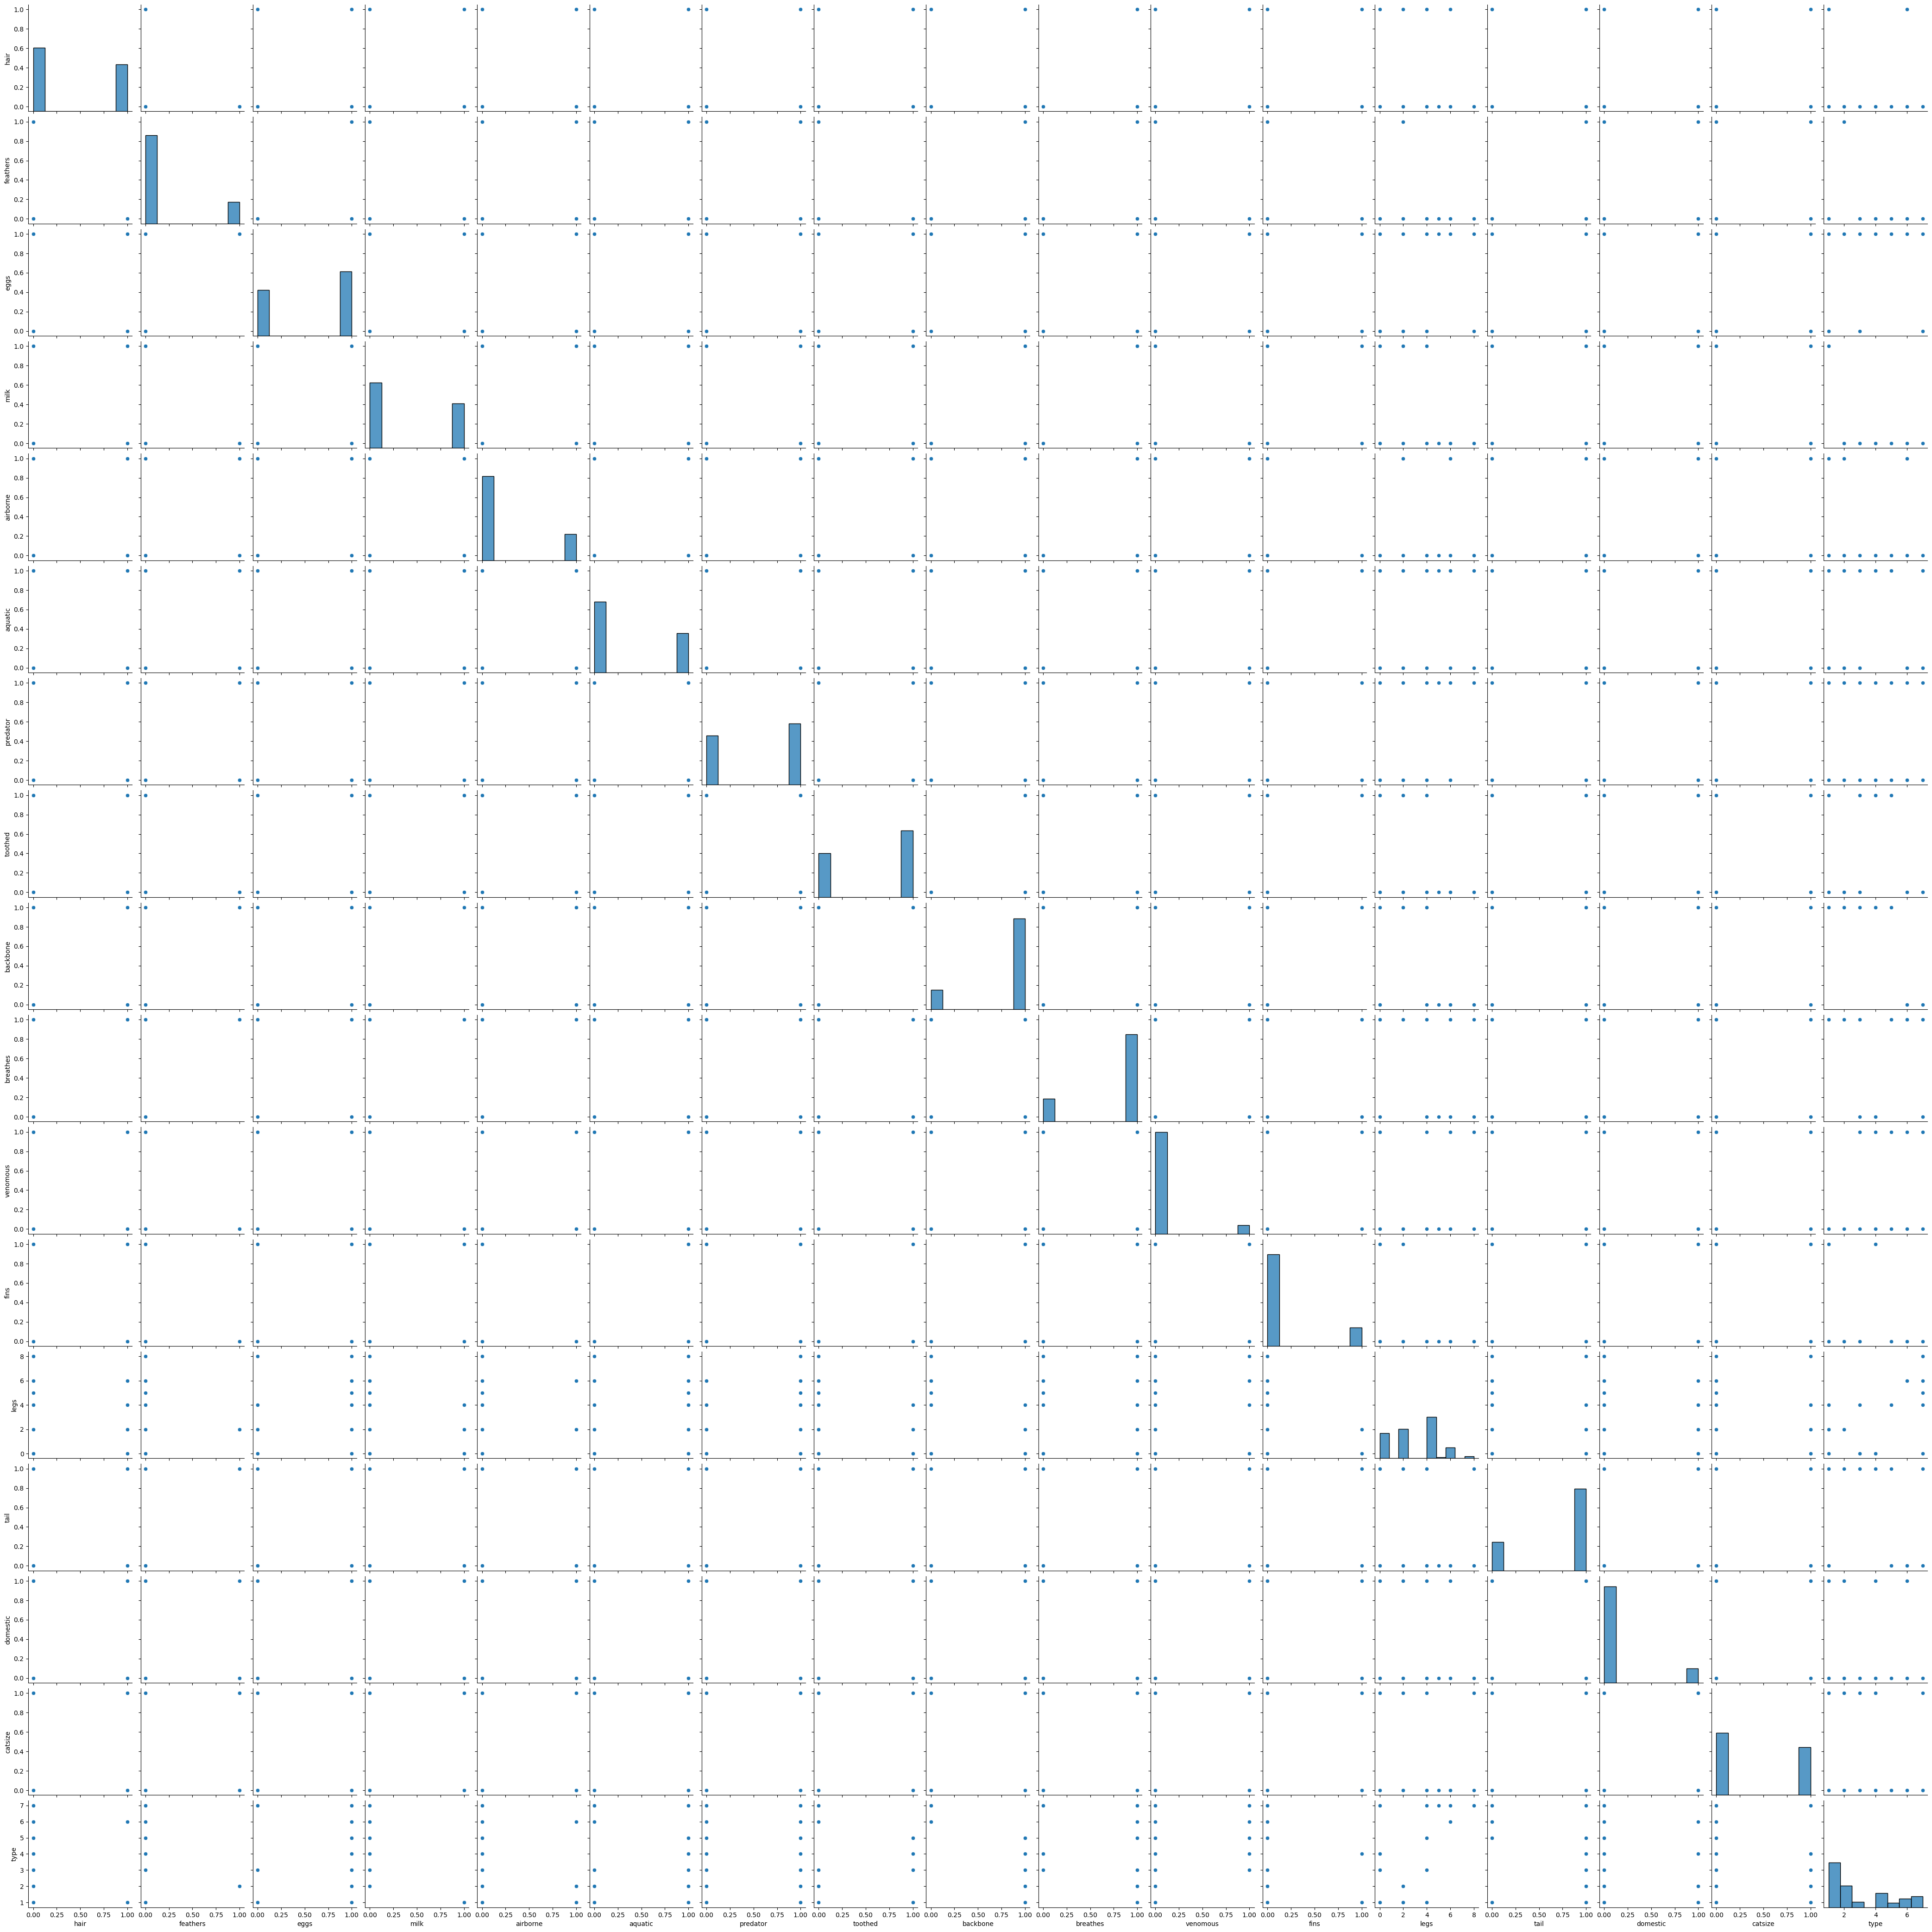

In [134]:
# Pair plots
sns.pairplot(df_z)
plt.show()

In [152]:
df_z

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [168]:
df_z1['animal name']

0      aardvark
1      antelope
2          bass
3          bear
4          boar
         ...   
96      wallaby
97         wasp
98         wolf
99         worm
100        wren
Name: animal name, Length: 101, dtype: object

In [170]:
df_z1.nunique()

animal name    100
hair             2
feathers         2
eggs             2
milk             2
airborne         2
aquatic          2
predator         2
toothed          2
backbone         2
breathes         2
venomous         2
fins             2
legs             6
tail             2
domestic         2
catsize          2
type             7
dtype: int64

In [172]:
# Correlation analysis

corr_chart=df_z.corr()
corr_chart

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
hair,1.000000,-0.427851,-0.817382,0.878503,-0.198431,-0.473554,-0.154769,0.492531,0.191681,0.441149,-0.104245,-0.280313,0.394009,0.048973,0.207208,0.455020,-0.562384
feathers,-0.427851,1.000000,0.419248,-0.410761,0.656553,-0.058552,-0.104430,-0.613631,0.231403,0.254588,-0.145739,-0.223541,-0.206686,0.292569,0.031586,-0.135934,-0.197520
eggs,-0.817382,0.419248,1.000000,-0.938848,0.376646,0.376244,0.011605,-0.642150,-0.340420,-0.382777,0.098689,0.164796,-0.224918,-0.221090,-0.155610,-0.514650,0.661825
milk,0.878503,-0.410761,-0.938848,1.000000,-0.366765,-0.362613,-0.029721,0.628168,0.384958,0.423527,-0.242449,-0.156328,0.214196,0.210026,0.163928,0.574906,-0.723683
airborne,-0.198431,0.656553,0.376646,-0.366765,1.000000,-0.172638,-0.295181,-0.594311,-0.104718,0.286039,0.008528,-0.251157,0.043712,0.009482,0.063274,-0.349768,0.022677
aquatic,-0.473554,-0.058552,0.376244,-0.362613,-0.172638,1.000000,0.375978,0.053150,0.022463,-0.637506,0.087915,0.604492,-0.360638,-0.034642,-0.224308,-0.111866,0.326639
predator,-0.154769,-0.104430,0.011605,-0.029721,-0.295181,0.375978,1.000000,0.129452,0.051022,-0.262931,0.115391,0.190302,-0.099723,0.018947,-0.309794,0.144790,0.061179
toothed,0.492531,-0.613631,-0.642150,0.628168,-0.594311,0.053150,0.129452,1.000000,0.575085,-0.065690,-0.062344,0.364292,-0.193476,0.310368,0.069430,0.344010,-0.471527
backbone,0.191681,0.231403,-0.340420,0.384958,-0.104718,0.022463,0.051022,0.575085,1.000000,0.207666,-0.246611,0.209499,-0.432856,0.731762,0.101733,0.356976,-0.828845
breathes,0.441149,0.254588,-0.382777,0.423527,0.286039,-0.637506,-0.262931,-0.065690,0.207666,1.000000,-0.120752,-0.617219,0.369868,0.088952,0.124068,0.204125,-0.519308


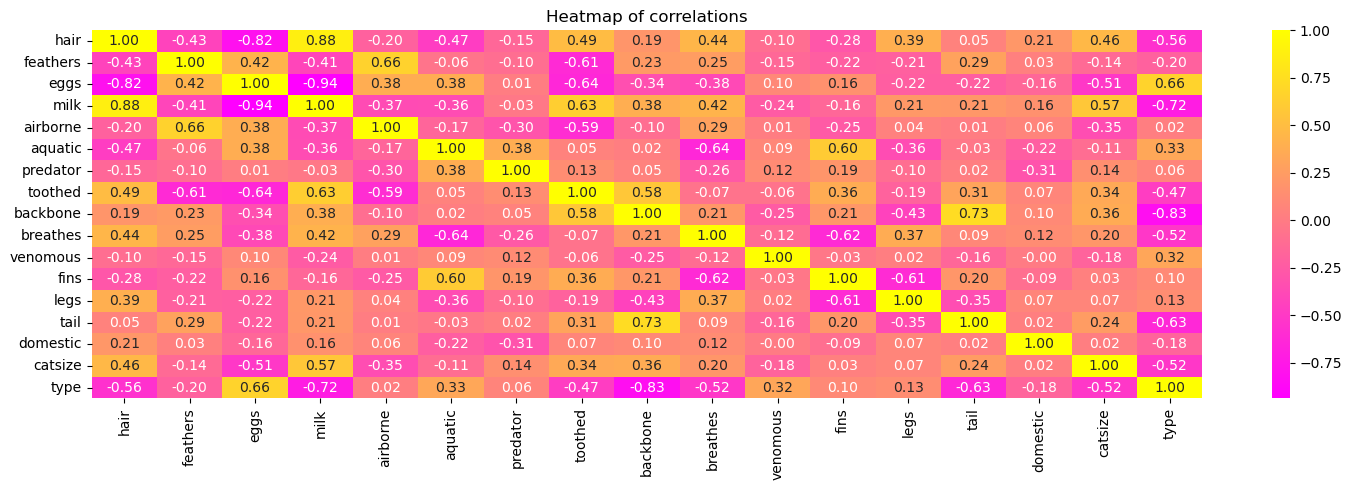

In [176]:
plt.figure(figsize=(15,5))
sns.heatmap(corr_chart, annot=True, cmap='spring',fmt='.2f')
plt.title('Heatmap of correlations')
plt.tight_layout()
plt.show()

In [178]:
# 0.88 - Strong positive correlation is shown between milk and hair. Hence one of the features can be removed. Dropping hair.

In [180]:
df_z=df_z.drop(columns=['hair'])

In [182]:
df_z

,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1
97,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6
98,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
99,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7


In [184]:
# Standardization of the independent variables

In [ ]:
# ### **How to Decide if Standardization is Needed for KNN on `zoo.csv`?**

# K-Nearest Neighbors (KNN) is a **distance-based** algorithm that relies on measuring distances between points. The choice to standardize or normalize data depends on the dataset's characteristics.

# ---

# ### **Step 1: Check Feature Types in `zoo.csv`**
# The `zoo.csv` dataset consists of **categorical and numerical features**, with an output class that categorizes animals.

# #### **Common Features in `zoo.csv`**
# - **Categorical (Binary) Features:**  
#   - `hair`, `feathers`, `eggs`, `milk`, `airborne`, `aquatic`, `predator`, `toothed`, etc.  
#   - These are mostly **binary (0/1)** and do **not** require standardization.
  
# - **Numerical Features:**  
#   - `legs`: The number of legs (values: 0, 2, 4, 5, 6, 8).  
#   - This is **numerical** and on a different scale than binary features.  
#   - Standardization **might** be useful to prevent this feature from dominating the distance calculation.

# - **Target Variable (`class_type`)**  
#   - The class variable categorizes animals (e.g., mammals, birds, reptiles).  
#   - **Do not standardize the target column**, as it's used for classification.

# ---

# ### **Step 2: When is Standardization Needed for KNN?**
# **👉 Standardization is needed if:**
# 1. The dataset has features with **different scales** (e.g., `legs` ranges from `0 to 8`, while other features are binary).
# 2. Distance-based algorithms like KNN can be **biased** towards features with larger magnitudes.

# **👉 Standardization is NOT needed if:**
# 1. All features are **binary (0/1)** (distance calculation will not be affected).
# 2. The dataset does not contain continuous numerical values with high variance.

# ---

# ### **Step 3: Apply Standardization Only If Needed**
# If we decide to standardize, apply **StandardScaler** from `sklearn` to numerical columns (`legs`):

# ```python
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# # Load dataset
# df = pd.read_csv("zoo.csv")

# # Select only numerical columns that need standardization
# num_cols = ["legs"]

# # Standardize numerical columns
# scaler = StandardScaler()
# df[num_cols] = scaler.fit_transform(df[num_cols])

# # Now, df is ready for KNN
# ```

# ---

# ### **Final Answer:**
# - **If using KNN without `legs` feature**, **standardization is not required**.  
# - **If `legs` is included**, it is recommended to **standardize it** to avoid bias in distance calculations.  
# - **Do not standardize binary categorical features or the target variable**.



In [ ]:
# ### **Should You Standardize Only the Non-Binary Features?**  
# Yes, you should **only standardize the non-binary features** (like `legs`) and **leave the binary features (0/1) unchanged**.  

# ### **Why Not Standardize Binary Columns?**  
# 1. **Binary values (0/1) are already on a standard scale**  
#    - Binary features already have a fixed range: `0` (absence) and `1` (presence).  
#    - Standardization (subtracting mean and dividing by standard deviation) **does not add value** for binary features.  

# 2. **Standardization can distort binary values**  
#    - If you standardize, the values will no longer be strictly `0` or `1`.  
#    - They will be transformed into floating-point numbers, which **may affect distance calculations** in KNN.

#    **Example:**
#    If `hair` (0/1) is standardized, it could become:  
#    - `hair = 0` → `-0.9`  
#    - `hair = 1` → `1.1`  
#    This transformation can introduce **unintended weight differences** in distance computation.

# 3. **Binary features are already comparable across samples**  
#    - Standardization is used when different features are on **vastly different scales** (e.g., `legs` ranging from `0 to 8`).  
#    - Binary features are inherently **scale-invariant**, meaning they do not overpower other features in distance-based methods.

# ### **Final Rule**  
# ✅ **Standardize only the continuous/numerical features (e.g., `legs`)**  
# ❌ **Do NOT standardize binary features (e.g., `hair`, `feathers`)**  



In [ ]:
# Standardize the feature 'legs'


In [429]:
df_z2=df_z.copy()

In [431]:
# Standardize the feature 'legs'

In [433]:
from sklearn.preprocessing import StandardScaler

In [437]:
scaler = StandardScaler()
df_z2['legs']=scaler.fit_transform(df_z2[['legs']])

In [441]:
df_z=df_z2.copy()

In [443]:
df_z

,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,0,0,1,0,0,1,1,1,1,0,0,0.572540,0,0,1,1
1,0,0,1,0,0,0,1,1,1,0,0,0.572540,1,0,1,1
2,0,1,0,0,1,1,1,1,0,0,1,-1.404435,1,0,0,4
3,0,0,1,0,0,1,1,1,1,0,0,0.572540,0,0,1,1
4,0,0,1,0,0,1,1,1,1,0,0,0.572540,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0,0,1,0,0,0,1,1,1,0,0,-0.415948,1,0,1,1
97,0,1,0,1,0,0,0,0,1,1,0,1.561027,0,0,0,6
98,0,0,1,0,0,1,1,1,1,0,0,0.572540,1,0,1,1
99,0,1,0,0,0,0,0,0,1,0,0,-1.404435,0,0,0,7


In [445]:
# Split the dataset into training and testing sets (80% training, 20% testing)

In [447]:
array=df_z.values


In [449]:
X=array[:,:-1]

In [451]:
X

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 1., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 1., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 1., 0., 0.]])

In [453]:
Y=array[:,-1]

In [455]:
Y

array([1., 1., 4., 1., 1., 1., 1., 4., 4., 1., 1., 2., 4., 7., 7., 7., 2.,
       1., 4., 1., 2., 2., 1., 2., 6., 5., 5., 1., 1., 1., 6., 1., 1., 2.,
       4., 1., 1., 2., 4., 6., 6., 2., 6., 2., 1., 1., 7., 1., 1., 1., 1.,
       6., 5., 7., 1., 1., 2., 2., 2., 2., 4., 4., 3., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 7., 4., 1., 1., 3., 7., 2., 2., 3., 7., 4., 2., 1.,
       7., 4., 2., 6., 5., 3., 3., 4., 1., 1., 2., 1., 6., 1., 7., 2.])

In [457]:
num_folds=10
kfold = KFold(n_splits=num_folds)

In [459]:
model=KNeighborsClassifier(n_neighbors=9)
results=cross_val_score(model,X,Y,cv=kfold)

In [461]:
results

array([1. , 0.6, 0.8, 1. , 0.9, 0.8, 0.8, 0.6, 0.6, 0.8])

In [463]:
print(results.mean())

0.7899999999999999


In [465]:
# Split the data into test and training sets

In [467]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [469]:
x_train,x_test,y_train,y_test=train_test_split(X,Y, test_size=0.2,random_state=42)


In [471]:
# Grid Search for Algorithm Tuning

In [473]:
from sklearn.model_selection import GridSearchCV

In [475]:
# Create KNN classifier

In [477]:
model=KNeighborsClassifier()

In [479]:
# Huperparameter tuning using GridSearchCV

In [481]:
# n_neighbors = np.array(range(1,11,2))
param_grid={'n_neighbors':np.arange(1,11,2),'metric':['euclidean','manhattan','minkowski','cosine','chebyshev','hamming']}
# param_grid=dict(n_neighbors=n_neighbors)
# Since k<=sqrt(n), sqrt of 100 is 10. So iterating through this range with odd 
# values of k

In [483]:
param_grid

{'n_neighbors': array([1, 3, 5, 7, 9]),
 'metric': ['euclidean',
  'manhattan',
  'minkowski',
  'cosine',
  'chebyshev',
  'hamming']}

In [485]:
# Hyperparameter tuning

In [493]:
grid=GridSearchCV(estimator=model, param_grid=param_grid,scoring ='accuracy')
grid=GridSearchCV(knn,param_grid,cv=10)
grid.fit(x_train,y_train)

C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


GridSearchCV(cv=10, estimator=KNeighborsClassifier(metric='euclidean'),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski',
                                    'cosine', 'chebyshev', 'hamming'],
                         'n_neighbors': array([1, 3, 5, 7, 9])})

In [ ]:
# Choosing the appropriate distance metric and value for k in K-Nearest Neighbors (KNN) depends on the specifics of your dataset and problem. Here’s how to make those choices:

# Choosing the Distance Metric
# Common Distance Metrics:
# Euclidean Distance: Most common and works well with continuous data.

# Manhattan Distance: Sum of absolute differences, suitable for grid-like data (e.g., images).

# Minkowski Distance: Generalization of Euclidean and Manhattan distances.


# Cosine Similarity: Measures the cosine of the angle between two vectors, good for text data.


# Hamming Distance: Used for categorical data, counts differing positions.


# Choosing the Metric:
# For continuous data, Euclidean or Manhattan distance is often used.

# For high-dimensional data, Cosine similarity can be effective.

# For categorical data, Hamming distance is appropriate.

# Choosing the Value of 'k'
# Cross-Validation: Use cross-validation to experiment with different values of k and determine the one that provides the best performance.

# Typically, values of k are chosen to be small odd numbers (like 3, 5, 7) to avoid ties.

# Domain Knowledge: Sometimes, domain-specific knowledge can guide the choice of k.

# Elbow Method: Plot the error rate against different values of k and look for the "elbow" point where the error starts to stabilize.

In [494]:
# Best parameters

In [495]:
print(f'Best k: {grid.best_params_["n_neighbors"]}')
print(f'Best distance metric: {grid.best_params_["metric"]}')

Best k: 3
Best distance metric: manhattan


In [499]:
print(grid.best_score_)
print(grid.best_params_)

0.9625
{'metric': 'manhattan', 'n_neighbors': 3}


In [501]:
# Visualizing the CV results

In [507]:
import matplotlib.pyplot as plt
%matplotlib inline

In [541]:

# Euclidean distance metric

# choose k between 1 to 11 - odd numbers
k_range = range(1,11,2)
k_scores = []

# Use iteration to calculator different k models, then return the average accuracy based
# on the cross validation

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train, y_train , cv=10)
    k_scores.append(scores.mean())

# pd.Series(k_scores).sort_values(ascending=False)

# Create a dataframe to clearly map k values to scores
k_df=pd.DataFrame({'k':k_range,'Accuracy':k_scores})

# Sort by accuracy in descending order
k_df=k_df.sort_values(by='Accuracy', ascending=False)
print(k_df)


C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


   k  Accuracy
0  1    0.9500
1  3    0.9375
2  5    0.9125
3  7    0.8750
4  9    0.7875


C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


In [545]:
# Manhattan distance metric


# choose k between 1 to 11 - odd numbers


k_range = range(1,11,2)
k_scores = []

# Use iteration to calculator different k models, then return the average accuracy based
# on the cross validation

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    scores = cross_val_score(knn, x_train, y_train , cv=10)
    k_scores.append(scores.mean())

# pd.Series(k_scores).sort_values(ascending=False)

# Create a dataframe to clearly map k values to scores
k_df=pd.DataFrame({'k':k_range,'Accuracy':k_scores})

# Sort by accuracy in descending order
k_df=k_df.sort_values(by='Accuracy', ascending=False)
print(k_df)


C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


   k  Accuracy
1  3    0.9625
0  1    0.9500
2  5    0.9500
3  7    0.9250
4  9    0.8500


C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


In [547]:
grid.best_estimator_

KNeighborsClassifier(metric='manhattan', n_neighbors=3)

In [549]:
# Evaluate the best model

from sklearn.metrics import accuracy_score

best_knn = grid.best_estimator_
y_pred = best_knn.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print (f'Accuracy:{accuracy}')

Accuracy:0.9523809523809523


In [551]:
from sklearn.metrics import classification_report

# Create KNN classifier with k=3
# knn=KNeighborsClassifier(n_neighbors=3)

# Train the model
# knn.fit(x_train,y_train)

# Make predictions on the test set
# y_pred1=knn.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print (f'Accuracy: {accuracy}')
print ('Classification Report:')
print (classification_report(y_test,y_pred))


Accuracy: 0.9523809523809523
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00         2
         3.0       0.00      0.00      0.00         1
         4.0       0.67      1.00      0.80         2
         6.0       1.00      1.00      1.00         3
         7.0       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [566]:
# Cross verifying the best hyper parameter

from sklearn.metrics import classification_report

# Create KNN classifier with k=3
knn=KNeighborsClassifier(n_neighbors=3, metric='manhattan')

# Train the model
knn.fit(x_train,y_train)

# Make predictions on the test set
y_pred1=knn.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred1)
print (f'Accuracy: {accuracy}')
print ('Classification Report:')
print (classification_report(y_test,y_pred1))


Accuracy: 0.9523809523809523
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00         2
         3.0       0.00      0.00      0.00         1
         4.0       0.67      1.00      0.80         2
         6.0       1.00      1.00      1.00         3
         7.0       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [577]:
# Evaluate the model with k=3, Euclidean

In [579]:
from sklearn.metrics import classification_report

# Create KNN classifier with k=3
knn=KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(x_train,y_train)

# Make predictions on the test set
y_pred1=knn.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred1)
print (f'Accuracy: {accuracy}')
print ('Classification Report:')
print (classification_report(y_test,y_pred1))


Accuracy: 0.9523809523809523
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00         2
         3.0       0.00      0.00      0.00         1
         4.0       0.67      1.00      0.80         2
         6.0       1.00      1.00      1.00         3
         7.0       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [581]:
# Evaluate the model with k=5, Euclidean

In [583]:
from sklearn.metrics import classification_report

# Create KNN classifier with k=5
knn=KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Train the model
knn.fit(x_train,y_train)

# Make predictions on the test set
y_pred1=knn.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred1)
print (f'Accuracy: {accuracy}')
print ('Classification Report:')
print (classification_report(y_test,y_pred1))


Accuracy: 0.9523809523809523
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00         2
         3.0       0.00      0.00      0.00         1
         4.0       0.67      1.00      0.80         2
         6.0       1.00      1.00      1.00         3
         7.0       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [585]:
# Evaluate the model with third best model, k=5 along with distance metric set as Euclidean

In [587]:
from sklearn.metrics import classification_report

# Create KNN classifier with k=5
knn=KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Train the model
knn.fit(x_train,y_train)

# Make predictions on the test set
y_pred1=knn.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred1)
print (f'Accuracy: {accuracy}')
print ('Classification Report:')
print (classification_report(y_test,y_pred1))


Accuracy: 0.9523809523809523
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        12
         2.0       1.00      1.00      1.00         2
         3.0       0.00      0.00      0.00         1
         4.0       0.67      1.00      0.80         2
         6.0       1.00      1.00      1.00         3
         7.0       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [590]:
# Visualize the desicion boundaries of the classifier

In [592]:
k_range

range(1, 11, 2)

In [594]:
k_scores

[0.95, 0.9625, 0.95, 0.925, 0.85]

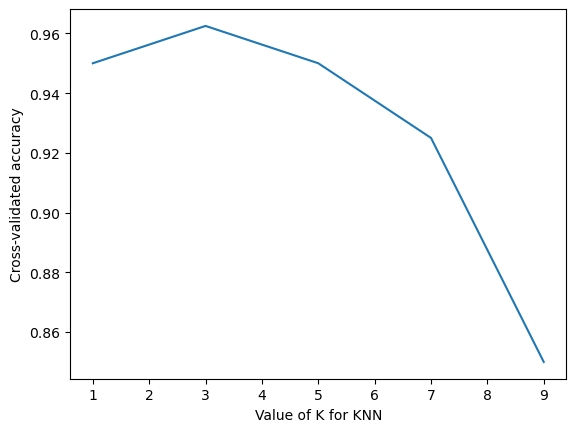

In [596]:
# Plot to see clearly

plt.plot(k_range,k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-validated accuracy')
plt.show()

In [598]:
# The highest cross validated accuracy is for k=1

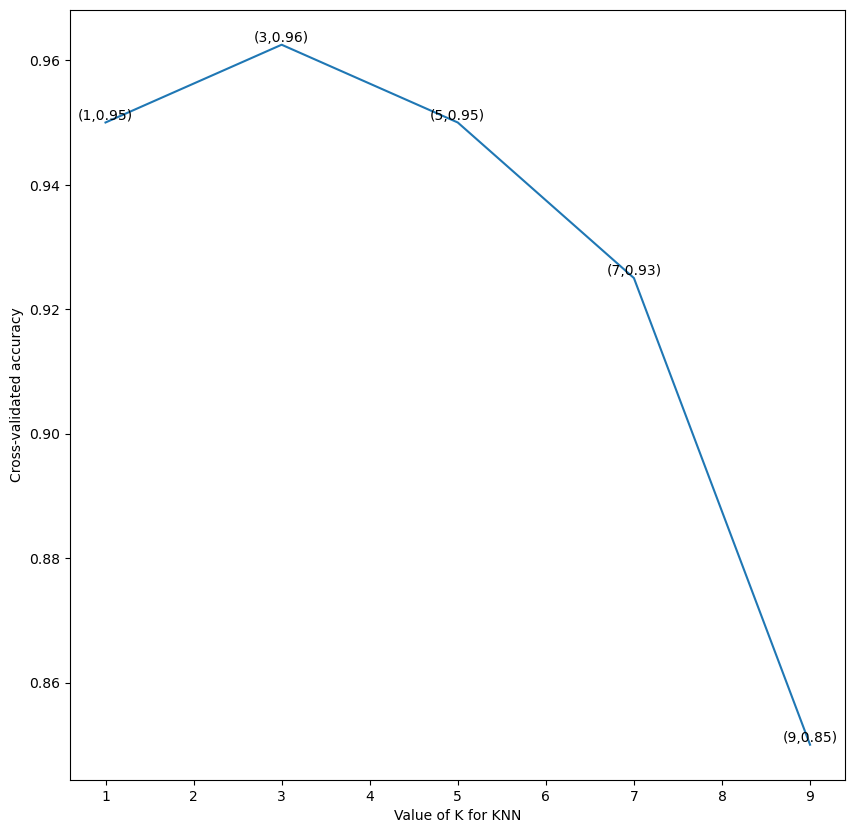

In [600]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(k_range,k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-validated accuracy')

# Adding x and y values as text annotations

for i, txt in enumerate(k_scores):
    plt.text(k_range[i], txt, f'({k_range[i]},{txt:.2f})',ha='center',va='bottom')

plt.show()

In [602]:
df_z.columns

Index(['feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator',
       'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail',
       'domestic', 'catsize', 'type'],
      dtype='object')

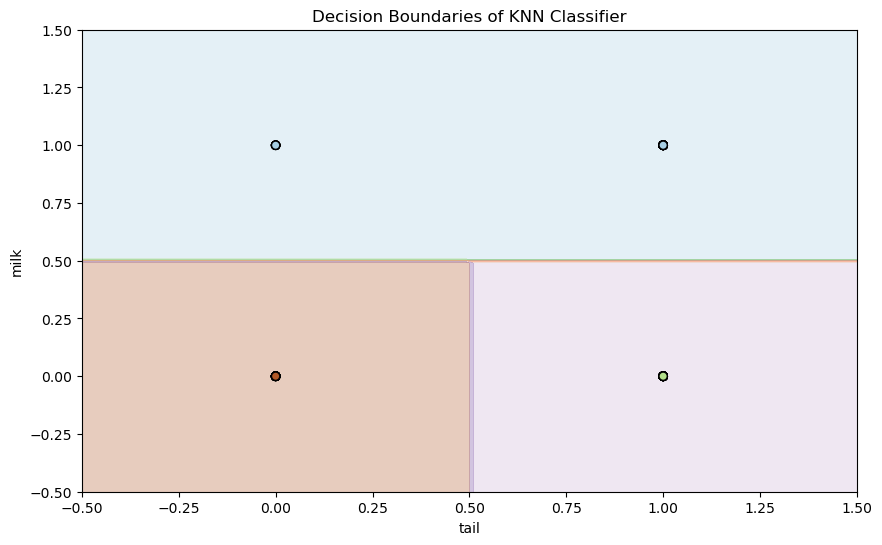

In [641]:
from sklearn.neighbors import KNeighborsClassifier

# Selecting two numerical features for visualization
features = ["tail", "milk"]  # Choose features that make sense biologically
XX = df_z[features].values
YY = df_z['type'].values #Assuming type is the target

# Scaling is already performed and not required for binary elements. Therefore not redoing standardizaton.

knn= KNeighborsClassifier(n_neighbors=3,metric = 'manhattan')
knn.fit(XX,YY)

# Create a mesh grid

x_min, x_max = XX[:, 0].min() - 0.5, XX[:, 0].max() + 0.5
y_min, y_max = XX[:, 1].min() - 0.5, XX[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict class for each point in the grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)





# Plot decision boundaries
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.scatter(XX[:, 0], XX[:, 1], c=YY, edgecolors="k", cmap=plt.cm.Paired)
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Decision Boundaries of KNN Classifier")
plt.show()

In [ ]:
# ✔ Feature Selection: Used backbone and milk for visualization (you can change them).
# ✔ Scaling: Applied StandardScaler() since KNN is distance-based.
# ✔ Mesh Grid: Generates test points to predict class labels.
# ✔ Contour Plot: Shows the classifier's decision boundaries.
# ✔ Scatter Plot: Plots actual data points over the decision regions.

In [ ]:
# Code explanation for mesh creation

In [ ]:
# x_min, x_max = XX[:, 0].min() - 0.5, XX[:, 0].max() + 0.5
# y_min, y_max = XX[:, 1].min() - 0.5, XX[:, 1].max() + 0.5
# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
#                      np.linspace(y_min, y_max, 100))
# Explaining the code line wise below:









# Sure! Let's break it down line by line:  

# ### **1st Line:**  
# ```python
# x_min, x_max = XX[:, 0].min() - 0.5, XX[:, 0].max() + 0.5
# ```
# - `XX[:, 0]` extracts all the values from the first feature (i.e., `"legs"` in your case).  
# - `.min()` and `.max()` find the minimum and maximum values of this feature.  
# - We subtract **0.5** from the minimum and add **0.5** to the maximum to slightly expand the range. This ensures that the decision boundary isn't 
# exactly on the edges of the data points but has some padding for better visualization.  

# ### **2nd Line:**  
# ```python
# y_min, y_max = XX[:, 1].min() - 0.5, XX[:, 1].max() + 0.5
# ```
# - This does the same thing as the first line but for the second feature (i.e., `"milk"`).  
# - Again, padding is added by subtracting and adding **0.5** to avoid boundaries touching the edge of the plot.  

# ### **3rd & 4th Lines:**  
# ```python
# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
#                      np.linspace(y_min, y_max, 100))
# ```
# - **`np.linspace(x_min, x_max, 100)`**  
#   - Creates 100 evenly spaced points between `x_min` and `x_max`.  
#   - These represent the X-axis grid points.  
# - **`np.linspace(y_min, y_max, 100)`**  
#   - Creates 100 evenly spaced points between `y_min` and `y_max`.  
#   - These represent the Y-axis grid points.  
# - **`np.meshgrid(...)`**  
#   - Creates a **grid of points** (xx, yy) over the feature space.  
#   - This is used to compute the classifier's decision boundary by predicting class labels at each grid point.  

# ### **Summary:**  
# This code creates a **2D grid** of (x, y) points covering the range of your two features (`legs` and `milk`). The next step will be to classify each 
# of these grid points using KNN and visualize the decision boundary. 🚀

In [ ]:
# # explain the code linewise-# Predict class for each point in the grid
# # Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
# # Z = Z.reshape(xx.shape)


# Explaining the code below:
# Sure! Let's break it down line by line:  

# ---

# ### **1st Line:**
# ```python
# Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
# ```
# #### What’s happening here?
# 1. **`xx.ravel()` and `yy.ravel()`**  
#    - `xx` and `yy` are **2D arrays** representing the mesh grid.
#    - `.ravel()` flattens them into **1D arrays**.
#    - Now, we have two **1D arrays**: one for X-coordinates and one for Y-coordinates.

# 2. **`np.c_[xx.ravel(), yy.ravel()]`**  
#    - `np.c_[]` is used for **column-wise concatenation**.
#    - This converts the **two 1D arrays** into a **2D array** where:
#      - The first column represents the X-values.
#      - The second column represents the Y-values.
#    - This results in a shape of `(10000, 2)`, assuming the mesh grid has **100 × 100** points.

# 3. **`knn.predict(...)`**  
#    - The trained **KNN classifier** (`knn`) predicts the class for **each grid point**.
#    - `Z` now contains **predicted class labels** for all points in the grid.

# ---

# ### **2nd Line:**
# ```python
# Z = Z.reshape(xx.shape)
# ```
# #### What’s happening here?
# - The predictions (`Z`) are in **1D format**.
# - `.reshape(xx.shape)` converts it **back into a 2D grid** that matches the original mesh grid (`xx`, `yy`).
# - This ensures the predicted classes align with the mesh grid, making it easier to **plot decision boundaries**.

# ---

# ### **Summary:**
# - First, we **flatten** the grid into a list of points and classify them.
# - Then, we **reshape** the predictions back into a 2D format for visualization.
# - This allows us to draw decision boundaries based on predicted classes. 🚀






In [ ]:
# # explain the code -> 
# # # Plot decision boundaries
# # plt.figure(figsize=(10, 6))
# # plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
# # plt.scatter(XX[:, 0], XX[:, 1], c=YY, edgecolors="k", cmap=plt.cm.Paired)
# # plt.xlabel(features[0])
# # plt.ylabel(features[1])
# # plt.title("Decision Boundaries of KNN Classifier")
# # plt.show()


# # Explaining the code below-





# ### **Breaking Down the Code Line by Line**

# ---

# ### **1st Line:**
# ```python
# plt.figure(figsize=(10, 6))
# ```
# - This **creates a new figure** for the plot.
# - `figsize=(10, 6)` sets the **size of the figure** (10 inches wide and 6 inches tall).

# ---

# ### **2nd Line:**
# ```python
# plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
# ```
# - **`plt.contourf(...)`** is used to **fill the decision regions** with different colors based on the predicted classes.
# - **Parameters:**
#   - `xx, yy`: The mesh grid coordinates.
#   - `Z`: The predicted class labels for each grid point (reshaped to match `xx` and `yy`).
#   - `alpha=0.3`: Controls the **transparency** of the colored decision regions.
#   - `cmap=plt.cm.Paired`: Defines the **color scheme** for different classes.

# ---

# ### **3rd Line:**
# ```python
# plt.scatter(XX[:, 0], XX[:, 1], c=YY, edgecolors="k", cmap=plt.cm.Paired)
# ```
# - **`plt.scatter(...)`** plots the **actual data points** (from the dataset) on top of the decision boundaries.
# - **Parameters:**
#   - `XX[:, 0]`: The first feature (X-axis values).
#   - `XX[:, 1]`: The second feature (Y-axis values).
#   - `c=YY`: Colors the points based on their actual class labels.
#   - `edgecolors="k"`: Gives each point a **black border** for better visibility.
#   - `cmap=plt.cm.Paired`: Uses the same color scheme as the decision boundaries.

# ⚠️ **Warning Message:**  
# > Matplotlib may give a warning like **"edgecolor is ignored for unfilled markers"** if using certain marker styles.

# ---

# ### **4th & 5th Lines:**
# ```python
# plt.xlabel(features[0])
# plt.ylabel(features[1])
# ```
# - **Labels the axes** with the feature names for better readability.

# ---

# ### **6th Line:**
# ```python
# plt.title("Decision Boundaries of KNN Classifier")
# ```
# - **Sets the title** of the plot.

# ---

# ### **7th Line:**
# ```python
# plt.show()
# ```
# - **Displays the plot**.

# ---

# ### **Final Output:**
# - A **scatter plot** of actual data points (colored by class).
# - **Decision regions** where different colors represent different predicted classes.
# - The plot helps **visualize how KNN classifies new data points** based on its decision boundaries.

# 🚀 **Now you can visually interpret how KNN is classifying data!**

